In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("../data/raw/air_quality/air_quality_historical.csv")

# Display first 5 rows
df.head()

,date,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust,uv_index,us_aqi,european_aqi
0,2022-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-08-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-08-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-08-04,60.378947,28.036842,495.210526,22.426316,24.389474,62.368421,0.806842,47.210526,2.100000,NaN,NaN
4,2022-08-05,58.337500,28.212500,507.416667,22.725000,24.879167,53.500000,0.794167,42.750000,1.527083,82.263158,63.0


In [2]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (1298, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1298 entries, 0 to 1297
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1298 non-null   object 
 1   pm10                   1295 non-null   float64
 2   pm2_5                  1295 non-null   float64
 3   carbon_monoxide        1295 non-null   float64
 4   nitrogen_dioxide       1295 non-null   float64
 5   sulphur_dioxide        1295 non-null   float64
 6   ozone                  1295 non-null   float64
 7   aerosol_optical_depth  1295 non-null   float64
 8   dust                   1295 non-null   float64
 9   uv_index               1295 non-null   float64
 10  us_aqi                 1294 non-null   float64
 11  european_aqi           1294 non-null   float64
dtypes: float64(11), object(1)
memory usage: 121.8+ KB


In [3]:
df.describe()

,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust,uv_index,us_aqi,european_aqi
count,1295.000000,1295.000000,1295.000000,1295.000000,1295.000000,1295.000000,1295.000000,1295.000000,1295.000000,1294.000000,1294.000000
mean,63.637600,31.144932,512.079184,21.952665,16.662633,74.826861,0.402093,53.166025,1.590021,91.840524,66.773828
std,31.374284,15.897951,335.943382,13.677442,12.135073,22.067406,0.234717,63.718920,0.526815,30.679871,17.326038
min,0.920833,0.650000,59.916667,0.000000,0.229167,30.375000,0.037083,0.000000,0.210417,15.500000,13.708333
25%,42.518750,20.575000,237.854167,11.072917,8.400000,59.145833,0.234375,12.145833,1.118750,69.406250,57.979167
50%,56.150000,26.870833,409.916667,17.958333,13.658333,71.500000,0.332917,30.833333,1.522917,82.541667,66.125000
75%,75.931250,37.014583,727.437500,29.362500,21.210417,87.312500,0.503750,71.604167,2.006250,106.489583,75.375000
max,294.483333,119.770833,2022.958333,97.483333,84.108333,205.250000,1.469583,563.833333,2.920833,214.625000,157.583333


In [4]:
df.isnull().sum()


date                     0
pm10                     3
pm2_5                    3
carbon_monoxide          3
nitrogen_dioxide         3
sulphur_dioxide          3
ozone                    3
aerosol_optical_depth    3
dust                     3
uv_index                 3
us_aqi                   4
european_aqi             4
dtype: int64

In [5]:
# Convert date column to datetime format
df["date"] = pd.to_datetime(df["date"])

# Sort data from oldest to newest
df = df.sort_values("date").reset_index(drop=True)

df.head()


,date,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust,uv_index,us_aqi,european_aqi
0,2022-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-08-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-08-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-08-04,60.378947,28.036842,495.210526,22.426316,24.389474,62.368421,0.806842,47.210526,2.100000,NaN,NaN
4,2022-08-05,58.337500,28.212500,507.416667,22.725000,24.879167,53.500000,0.794167,42.750000,1.527083,82.263158,63.0


In [6]:
# Remove rows containing missing values
df = df.dropna().reset_index(drop=True)

# Check again
print(df.isnull().sum())

# Check new dataset shape
print("Dataset Shape:", df.shape)

df.head()

date                     0
pm10                     0
pm2_5                    0
carbon_monoxide          0
nitrogen_dioxide         0
sulphur_dioxide          0
ozone                    0
aerosol_optical_depth    0
dust                     0
uv_index                 0
us_aqi                   0
european_aqi             0
dtype: int64
Dataset Shape: (1294, 12)


,date,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust,uv_index,us_aqi,european_aqi
0,2022-08-05,58.337500,28.212500,507.416667,22.725000,24.879167,53.500000,0.794167,42.750000,1.527083,82.263158,63.000000
1,2022-08-06,51.716667,27.466667,431.958333,22.137500,19.204167,44.166667,0.877500,31.666667,0.925000,83.833333,62.583333
2,2022-08-07,89.125000,57.629167,944.125000,39.291667,42.908333,148.083333,0.682917,15.458333,1.920833,147.250000,76.125000
3,2022-08-08,103.129167,64.520833,1150.500000,46.795833,55.066667,122.875000,0.690000,24.458333,1.685417,176.750000,89.458333
4,2022-08-09,77.562500,54.037500,849.000000,50.870833,45.220833,84.291667,0.574167,1.375000,1.270833,152.500000,88.625000


In [7]:
print("Start date:", df["date"].min())
print("End date:", df["date"].max())
print("Total days:", len(df))

Start date: 2022-08-05 00:00:00
End date: 2026-02-18 00:00:00
Total days: 1294


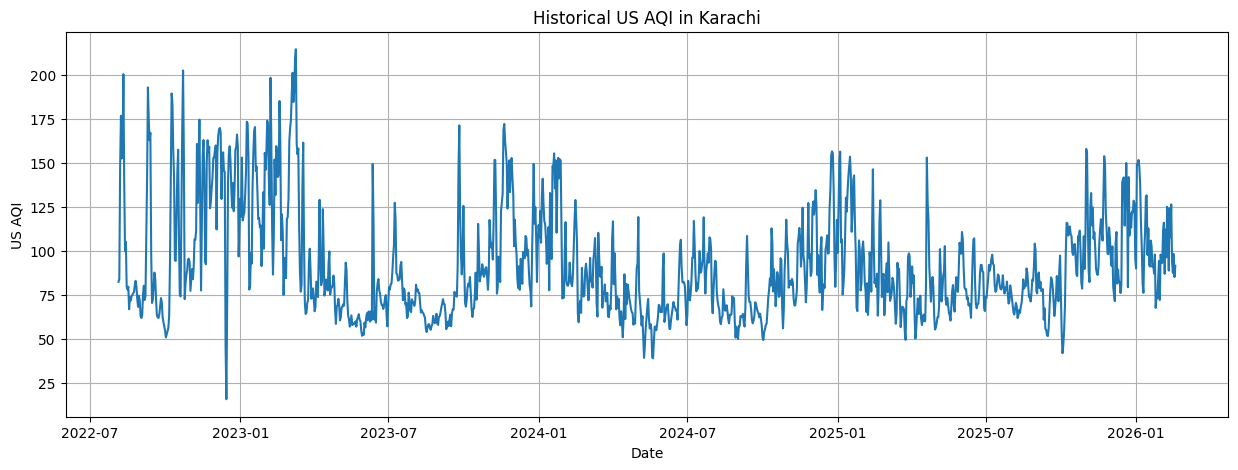

In [8]:
plt.figure(figsize=(15, 5))

plt.plot(df["date"], df["us_aqi"])

plt.title("Historical US AQI in Karachi")
plt.xlabel("Date")
plt.ylabel("US AQI")

plt.grid()

plt.show()

In [9]:
# Create time-based features
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.dayofweek

In [10]:
df[["date", "year", "month", "day", "day_of_week"]].head()

,date,year,month,day,day_of_week
0,2022-08-05,2022,8,5,4
1,2022-08-06,2022,8,6,5
2,2022-08-07,2022,8,7,6
3,2022-08-08,2022,8,8,0
4,2022-08-09,2022,8,9,1


In [11]:
# Create historical AQI features
df["us_aqi_lag_1"] = df["us_aqi"].shift(1)
df["us_aqi_lag_3"] = df["us_aqi"].shift(3)
df["us_aqi_lag_7"] = df["us_aqi"].shift(7)

In [12]:
df[[
    "date",
    "us_aqi",
    "us_aqi_lag_1",
    "us_aqi_lag_3",
    "us_aqi_lag_7"
]].head(10)

,date,us_aqi,us_aqi_lag_1,us_aqi_lag_3,us_aqi_lag_7
0,2022-08-05,82.263158,NaN,NaN,NaN
1,2022-08-06,83.833333,82.263158,NaN,NaN
2,2022-08-07,147.250000,83.833333,NaN,NaN
3,2022-08-08,176.750000,147.250000,82.263158,NaN
4,2022-08-09,152.500000,176.750000,83.833333,NaN
5,2022-08-10,157.666667,152.500000,147.250000,NaN
6,2022-08-11,200.416667,157.666667,176.750000,NaN
7,2022-08-12,138.375000,200.416667,152.500000,82.263158
8,2022-08-13,99.750000,138.375000,157.666667,83.833333
9,2022-08-14,105.083333,99.750000,200.416667,147.250000


In [13]:
# Create rolling average features
df["us_aqi_roll_3"] = df["us_aqi"].shift(1).rolling(window=3).mean()
df["us_aqi_roll_7"] = df["us_aqi"].shift(1).rolling(window=7).mean()

# Create rolling standard deviation
df["us_aqi_roll_std_7"] = df["us_aqi"].shift(1).rolling(window=7).std()

df.head(10)

,date,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust,uv_index,...,year,month,day,day_of_week,us_aqi_lag_1,us_aqi_lag_3,us_aqi_lag_7,us_aqi_roll_3,us_aqi_roll_7,us_aqi_roll_std_7
0,2022-08-05,58.337500,28.212500,507.416667,22.725000,24.879167,53.500000,0.794167,42.750000,1.527083,...,2022,8,5,4,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-08-06,51.716667,27.466667,431.958333,22.137500,19.204167,44.166667,0.877500,31.666667,0.925000,...,2022,8,6,5,82.263158,NaN,NaN,NaN,NaN,NaN
2,2022-08-07,89.125000,57.629167,944.125000,39.291667,42.908333,148.083333,0.682917,15.458333,1.920833,...,2022,8,7,6,83.833333,NaN,NaN,NaN,NaN,NaN
3,2022-08-08,103.129167,64.520833,1150.500000,46.795833,55.066667,122.875000,0.690000,24.458333,1.685417,...,2022,8,8,0,147.250000,82.263158,NaN,104.448830,NaN,NaN
4,2022-08-09,77.562500,54.037500,849.000000,50.870833,45.220833,84.291667,0.574167,1.375000,1.270833,...,2022,8,9,1,176.750000,83.833333,NaN,135.944444,NaN,NaN
5,2022-08-10,156.366667,108.387500,1297.583333,65.391667,51.662500,104.791667,0.548750,4.416667,1.379167,...,2022,8,10,2,152.500000,147.250000,NaN,158.833333,NaN,NaN
6,2022-08-11,122.845833,83.287500,1163.041667,49.070833,52.008333,146.291667,0.545000,10.166667,1.537500,...,2022,8,11,3,157.666667,176.750000,NaN,162.305556,NaN,NaN
7,2022-08-12,49.291667,31.216667,605.750000,34.491667,32.987500,82.208333,0.370000,13.583333,1.337500,...,2022,8,12,4,200.416667,152.500000,82.263158,170.194444,142.954261,44.625859
8,2022-08-13,48.941667,32.137500,704.000000,35.566667,49.345833,94.000000,0.260000,3.083333,1.954167,...,2022,8,13,5,138.375000,157.666667,83.833333,165.486111,150.970238,36.139941
9,2022-08-14,39.908333,24.970833,475.916667,20.325000,27.833333,99.500000,0.312917,3.375000,2.043750,...,2022,8,14,6,99.750000,200.416667,147.250000,146.180556,153.244048,31.402042


In [14]:
# Create target: next day's AQI
df["target_us_aqi"] = df["us_aqi"].shift(-1)

# Check important columns
df[[
    "date",
    "us_aqi",
    "us_aqi_lag_1",
    "us_aqi_roll_3",
    "us_aqi_roll_7",
    "us_aqi_roll_std_7",
    "target_us_aqi"
]].head(10)

,date,us_aqi,us_aqi_lag_1,us_aqi_roll_3,us_aqi_roll_7,us_aqi_roll_std_7,target_us_aqi
0,2022-08-05,82.263158,NaN,NaN,NaN,NaN,83.833333
1,2022-08-06,83.833333,82.263158,NaN,NaN,NaN,147.250000
2,2022-08-07,147.250000,83.833333,NaN,NaN,NaN,176.750000
3,2022-08-08,176.750000,147.250000,104.448830,NaN,NaN,152.500000
4,2022-08-09,152.500000,176.750000,135.944444,NaN,NaN,157.666667
5,2022-08-10,157.666667,152.500000,158.833333,NaN,NaN,200.416667
6,2022-08-11,200.416667,157.666667,162.305556,NaN,NaN,138.375000
7,2022-08-12,138.375000,200.416667,170.194444,142.954261,44.625859,99.750000
8,2022-08-13,99.750000,138.375000,165.486111,150.970238,36.139941,105.083333
9,2022-08-14,105.083333,99.750000,146.180556,153.244048,31.402042,79.541667


In [15]:
# Remove rows with missing values
df = df.dropna().reset_index(drop=True)

# Check the cleaned dataset
print("Dataset shape after cleaning:", df.shape)

df[[
    "date",
    "us_aqi",
    "us_aqi_lag_1",
    "us_aqi_lag_3",
    "us_aqi_lag_7",
    "us_aqi_roll_3",
    "us_aqi_roll_7",
    "us_aqi_roll_std_7",
    "target_us_aqi"
]].head()

Dataset shape after cleaning: (1286, 23)


,date,us_aqi,us_aqi_lag_1,us_aqi_lag_3,us_aqi_lag_7,us_aqi_roll_3,us_aqi_roll_7,us_aqi_roll_std_7,target_us_aqi
0,2022-08-12,138.375000,200.416667,152.500000,82.263158,170.194444,142.954261,44.625859,99.750000
1,2022-08-13,99.750000,138.375000,157.666667,83.833333,165.486111,150.970238,36.139941,105.083333
2,2022-08-14,105.083333,99.750000,200.416667,147.250000,146.180556,153.244048,31.402042,79.541667
3,2022-08-15,79.541667,105.083333,138.375000,176.750000,114.402778,147.220238,36.391508,77.958333
4,2022-08-16,77.958333,79.541667,99.750000,152.500000,94.791667,133.333333,41.441747,79.541667


In [16]:
# Define target
target = "target_us_aqi"

# Define feature columns
features = [col for col in df.columns if col not in ["date", target]]

# Create X and y
X = df[features]
y = df[target]

print("Number of features:", len(features))
print("\nFeatures:")
print(features)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Number of features: 21

Features:
['pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'aerosol_optical_depth', 'dust', 'uv_index', 'us_aqi', 'european_aqi', 'year', 'month', 'day', 'day_of_week', 'us_aqi_lag_1', 'us_aqi_lag_3', 'us_aqi_lag_7', 'us_aqi_roll_3', 'us_aqi_roll_7', 'us_aqi_roll_std_7']

X shape: (1286, 21)
y shape: (1286,)


In [17]:
# Calculate split points
n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

# Chronological split
X_train = X.iloc[:train_end]
X_val = X.iloc[train_end:val_end]
X_test = X.iloc[val_end:]

y_train = y.iloc[:train_end]
y_val = y.iloc[train_end:val_end]
y_test = y.iloc[val_end:]

# Display dataset sizes
print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

# Display date ranges
print("\nTraining period:")
print(df["date"].iloc[0], "to", df["date"].iloc[train_end - 1])

print("\nValidation period:")
print(df["date"].iloc[train_end], "to", df["date"].iloc[val_end - 1])

print("\nTest period:")
print(df["date"].iloc[val_end], "to", df["date"].iloc[-1])

Training set: (900, 21) (900,)
Validation set: (193, 21) (193,)
Test set: (193, 21) (193,)

Training period:
2022-08-12 00:00:00 to 2025-01-27 00:00:00

Validation period:
2025-01-28 00:00:00 to 2025-08-08 00:00:00

Test period:
2025-08-09 00:00:00 to 2026-02-17 00:00:00


In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Baseline prediction:
# Predict tomorrow's AQI using today's AQI
baseline_pred = X_val["us_aqi"]

# Calculate errors
baseline_mae = mean_absolute_error(y_val, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_val, baseline_pred))

print("Baseline Validation Results")
print("MAE:", round(baseline_mae, 2))
print("RMSE:", round(baseline_rmse, 2))

Baseline Validation Results
MAE: 9.39
RMSE: 13.39


In [19]:
#Random Forest

from sklearn.ensemble import RandomForestRegressor

# Create the Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest training completed.")

Random Forest training completed.


In [20]:
# Make predictions on validation data
rf_val_pred = rf_model.predict(X_val)

# Calculate validation errors
rf_val_mae = mean_absolute_error(y_val, rf_val_pred)
rf_val_rmse = np.sqrt(mean_squared_error(y_val, rf_val_pred))

print("Random Forest Validation Results")
print("MAE:", round(rf_val_mae, 2))
print("RMSE:", round(rf_val_rmse, 2))

print("\nComparison with Baseline")
print("Baseline MAE:", round(baseline_mae, 2))
print("Random Forest MAE:", round(rf_val_mae, 2))

print("Baseline RMSE:", round(baseline_rmse, 2))
print("Random Forest RMSE:", round(rf_val_rmse, 2))

Random Forest Validation Results
MAE: 5.5
RMSE: 7.38

Comparison with Baseline
Baseline MAE: 9.39
Random Forest MAE: 5.5
Baseline RMSE: 13.39
Random Forest RMSE: 7.38


In [21]:
import pandas as pd

# Get feature names from X
feature_names = X.columns

# Get feature importance
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

print(feature_importance)

                  feature  importance
1                   pm2_5    0.885074
5                   ozone    0.014764
4         sulphur_dioxide    0.010904
8                uv_index    0.009352
10           european_aqi    0.008691
9                  us_aqi    0.008258
20      us_aqi_roll_std_7    0.006166
16           us_aqi_lag_3    0.005956
0                    pm10    0.005056
15           us_aqi_lag_1    0.004923
13                    day    0.004920
6   aerosol_optical_depth    0.004821
19          us_aqi_roll_7    0.004491
17           us_aqi_lag_7    0.004180
18          us_aqi_roll_3    0.004147
7                    dust    0.003943
3        nitrogen_dioxide    0.003837
2         carbon_monoxide    0.003405
12                  month    0.002698
11                   year    0.002222
14            day_of_week    0.002195


In [22]:
# Remove the redundant European AQI feature
features_clean = [
    col for col in features
    if col != "european_aqi"
]

# Create clean feature datasets
X_clean = df[features_clean]

X_train_clean = X_clean.iloc[:train_end]
X_val_clean = X_clean.iloc[train_end:val_end]

# Train Random Forest again
rf_clean = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_clean.fit(X_train_clean, y_train)

# Validate
rf_clean_pred = rf_clean.predict(X_val_clean)

clean_mae = mean_absolute_error(y_val, rf_clean_pred)
clean_rmse = np.sqrt(
    mean_squared_error(y_val, rf_clean_pred)
)

print("Random Forest without European AQI")
print("MAE:", round(clean_mae, 2))
print("RMSE:", round(clean_rmse, 2))

Random Forest without European AQI
MAE: 5.68
RMSE: 7.62


In [23]:
!pip install xgboost

You should consider upgrading via the 'C:\Users\MUB\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [24]:
from xgboost import XGBRegressor

# Create XGBoost model
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# Train
xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost training completed.")

XGBoost training completed.


In [25]:
# Predictions
xgb_val_pred = xgb_model.predict(X_val)

# Evaluation
xgb_val_mae = mean_absolute_error(y_val, xgb_val_pred)
xgb_val_rmse = np.sqrt(
    mean_squared_error(y_val, xgb_val_pred)
)

print("XGBoost Validation Results")
print("MAE:", round(xgb_val_mae, 2))
print("RMSE:", round(xgb_val_rmse, 2))

XGBoost Validation Results
MAE: 5.56
RMSE: 7.66


In [26]:
from sklearn.model_selection import ParameterGrid

# Different parameter combinations to test
param_grid = {
    "n_estimators": [300, 500],
    "max_depth": [8, 10, 15, None],
    "min_samples_leaf": [1, 2, 4],
    "max_features": [0.7, 1.0]
}

results = []

for params in ParameterGrid(param_grid):

    model = RandomForestRegressor(
        **params,
        random_state=42,
        n_jobs=-1
    )

    # Train
    model.fit(X_train, y_train)

    # Validate
    predictions = model.predict(X_val)

    mae = mean_absolute_error(y_val, predictions)
    rmse = np.sqrt(mean_squared_error(y_val, predictions))

    results.append({
        **params,
        "MAE": mae,
        "RMSE": rmse
    })

# Convert results to DataFrame
tuning_results = pd.DataFrame(results)

# Sort by MAE
tuning_results = tuning_results.sort_values(
    by="MAE"
).reset_index(drop=True)

# Show best results
print(tuning_results.head(10))

   max_depth  max_features  min_samples_leaf  n_estimators       MAE      RMSE
0        8.0           1.0                 4           500  5.397457  7.225099
1        8.0           1.0                 4           300  5.404755  7.219874
2        8.0           1.0                 1           500  5.409358  7.315843
3        8.0           1.0                 1           300  5.426804  7.343499
4        8.0           1.0                 2           500  5.441251  7.320784
5       10.0           1.0                 4           500  5.441384  7.245951
6       10.0           1.0                 4           300  5.444489  7.244244
7        NaN           1.0                 4           500  5.454587  7.264055
8       15.0           1.0                 4           500  5.454687  7.263909
9        NaN           1.0                 4           300  5.454820  7.262828


In [27]:
# Combine training and validation data
X_train_final = pd.concat([X_train, X_val])
y_train_final = pd.concat([y_train, y_val])

# Train final Random Forest with the best parameters
final_rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=8,
    max_features=1.0,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)

final_rf_model.fit(X_train_final, y_train_final)

print("Final Random Forest model trained successfully.")
print("Training samples:", X_train_final.shape[0])
print("Test samples kept separate:", X_test.shape[0])

Final Random Forest model trained successfully.
Training samples: 1093
Test samples kept separate: 193


In [28]:
# Make predictions on the untouched test set
final_test_pred = final_rf_model.predict(X_test)

# Calculate final evaluation metrics
final_test_mae = mean_absolute_error(y_test, final_test_pred)

final_test_rmse = np.sqrt(
    mean_squared_error(y_test, final_test_pred)
)

# Print final results
print("Final Test Results")
print("MAE:", round(final_test_mae, 2))
print("RMSE:", round(final_test_rmse, 2))

Final Test Results
MAE: 7.36
RMSE: 10.31


In [29]:
# Baseline prediction:
# Predict tomorrow's AQI using today's AQI

baseline_test_pred = X_test["us_aqi"].values

baseline_test_mae = mean_absolute_error(
    y_test,
    baseline_test_pred
)

baseline_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_test_pred
    )
)

print("Baseline Test Results")
print("MAE:", round(baseline_test_mae, 2))
print("RMSE:", round(baseline_test_rmse, 2))

Baseline Test Results
MAE: 11.87
RMSE: 16.67


In [30]:
print("\nModel Improvement over Baseline")

mae_improvement = (
    (baseline_test_mae - final_test_mae)
    / baseline_test_mae
) * 100

rmse_improvement = (
    (baseline_test_rmse - final_test_rmse)
    / baseline_test_rmse
) * 100

print(
    "MAE improvement:",
    round(mae_improvement, 2),
    "%"
)

print(
    "RMSE improvement:",
    round(rmse_improvement, 2),
    "%"
)


Model Improvement over Baseline
MAE improvement: 38.02 %
RMSE improvement: 38.13 %


In [31]:
from sklearn.metrics import r2_score

final_test_r2 = r2_score(y_test, final_test_pred)

print("Final Test R² Score:", round(final_test_r2, 4))

Final Test R² Score: 0.8109


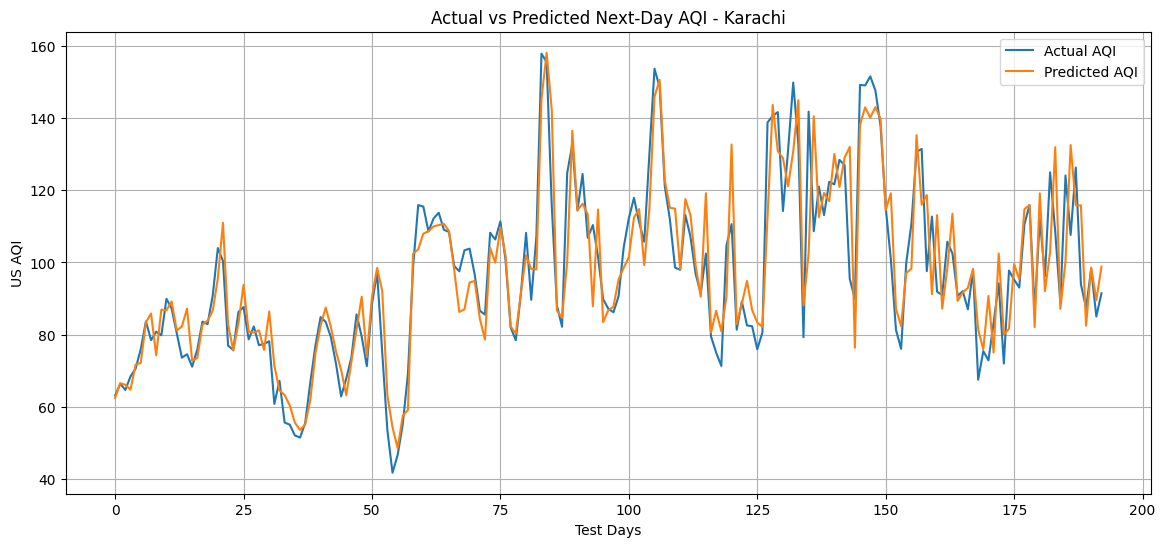

In [32]:
import matplotlib.pyplot as plt

# Plot actual vs predicted AQI
plt.figure(figsize=(14, 6))

plt.plot(
    y_test.values,
    label="Actual AQI"
)

plt.plot(
    final_test_pred,
    label="Predicted AQI"
)

plt.title("Actual vs Predicted Next-Day AQI - Karachi")
plt.xlabel("Test Days")
plt.ylabel("US AQI")
plt.legend()
plt.grid(True)

plt.show()

In [33]:
import os
import joblib

# Create models folder
os.makedirs("models", exist_ok=True)

# Save the model
joblib.dump(
    final_rf_model,
    "models/aqi_random_forest.joblib"
)

print("Model saved successfully.")

Model saved successfully.


In [34]:
# Save feature names in the exact training order

feature_config = {
    "features": list(X.columns),
    "target": "target_us_aqi",
    "forecast_horizon": "1 day",
    "city": "Karachi",
    "country": "Pakistan"
}

joblib.dump(
    feature_config,
    "models/feature_config.joblib"
)

print("Feature configuration saved successfully.")
print("\nFeatures used by the model:")
for i, feature in enumerate(feature_config["features"], start=1):
    print(f"{i}. {feature}")

Feature configuration saved successfully.

Features used by the model:
1. pm10
2. pm2_5
3. carbon_monoxide
4. nitrogen_dioxide
5. sulphur_dioxide
6. ozone
7. aerosol_optical_depth
8. dust
9. uv_index
10. us_aqi
11. european_aqi
12. year
13. month
14. day
15. day_of_week
16. us_aqi_lag_1
17. us_aqi_lag_3
18. us_aqi_lag_7
19. us_aqi_roll_3
20. us_aqi_roll_7
21. us_aqi_roll_std_7


In [35]:
import joblib

joblib.dump(final_rf_model, "karachi_aqi_random_forest.pkl")

print("Model saved successfully!")

Model saved successfully!


In [36]:
joblib.dump(feature_names, "feature_names.pkl")

print("Feature names saved successfully!")

Feature names saved successfully!


In [37]:
import joblib

loaded_model = joblib.load("karachi_aqi_random_forest.pkl")
loaded_feature_names = joblib.load("feature_names.pkl")

print("Model loaded successfully!")
print("Number of expected features:", len(loaded_feature_names))
print("\nExpected features:")
for i, feature in enumerate(loaded_feature_names, start=1):
    print(f"{i}. {feature}")

Model loaded successfully!
Number of expected features: 21

Expected features:
1. pm10
2. pm2_5
3. carbon_monoxide
4. nitrogen_dioxide
5. sulphur_dioxide
6. ozone
7. aerosol_optical_depth
8. dust
9. uv_index
10. us_aqi
11. european_aqi
12. year
13. month
14. day
15. day_of_week
16. us_aqi_lag_1
17. us_aqi_lag_3
18. us_aqi_lag_7
19. us_aqi_roll_3
20. us_aqi_roll_7
21. us_aqi_roll_std_7


In [38]:
# Take one sample from the test set
sample_input = X_test.iloc[[0]]

# Actual next-day AQI
actual_aqi = y_test.iloc[0]

# Predict using the loaded model
predicted_aqi = loaded_model.predict(sample_input)[0]

print("Actual next-day AQI:", round(actual_aqi, 2))
print("Predicted next-day AQI:", round(predicted_aqi, 2))
print("Prediction error:", round(abs(actual_aqi - predicted_aqi), 2))

Actual next-day AQI: 63.08
Predicted next-day AQI: 62.4
Prediction error: 0.68
